<a href="https://colab.research.google.com/github/HanniJaviera/Challenge-Telecom-X-Part-Two/blob/main/Challenge_TelecomX_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preparación de los datos**

1. Extracción y Limpieza de Columnas Irrelevantes

In [1]:
import pandas as pd
import numpy as np

df_ml = pd.read_csv("datos_tratados.csv")

if 'ID_Cliente' in df_ml.columns:
    df_ml = df_ml.drop(columns=['ID_Cliente'])

print(f"Dataset cargado. Filas: {df_ml.shape[0]}, Columnas: {df_ml.shape[1]}")
df_ml.head()

Dataset cargado. Filas: 7043, Columnas: 23


,customerID,Abandono,Genero,Adulto_Mayor,customer_Partner,customer_Dependents,Meses_Antiguedad,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,Tipo_Contrato,account_PaperlessBilling,Metodo_Pago,Cargo_Mensual,account_Charges_Total,Cargo_Diario,Conteo_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,3
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,1
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,4
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,2


2. Encoding (Codificación de Variables)

In [2]:
df_encoded = pd.get_dummies(df_ml, drop_first=True)

print(f"Columnas después del Encoding: {df_encoded.shape[1]}")

Columnas después del Encoding: 7075


3. Verificación de la Proporción de Abandono

In [3]:
proporcion = df_encoded['Abandono'].value_counts(normalize=True) * 100
print("Proporción de Clientes:")
print(f"Se quedan (0): {proporcion[0]:.2f}%")
print(f"Se van (1): {proporcion[1]:.2f}%")

Proporción de Clientes:
Se quedan (0): 73.46%
Se van (1): 26.54%


4. Balanceo de Clases (SMOTE)

In [4]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Abandono', axis=1)
y = df_encoded['Abandono']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Balanceo completado. Ahora tenemos {len(y_train_res)} ejemplos de entrenamiento (50/50).")

Balanceo completado. Ahora tenemos 8278 ejemplos de entrenamiento (50/50).


5. Estandarización

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)

X_test_scaled = scaler.transform(X_test)

print("Datos estandarizados y listos para el modelado.")

Datos estandarizados y listos para el modelado.


# **Correlación y Selección de Variables**

1. Limpieza de Dimensionalidad y Matriz de Correlación

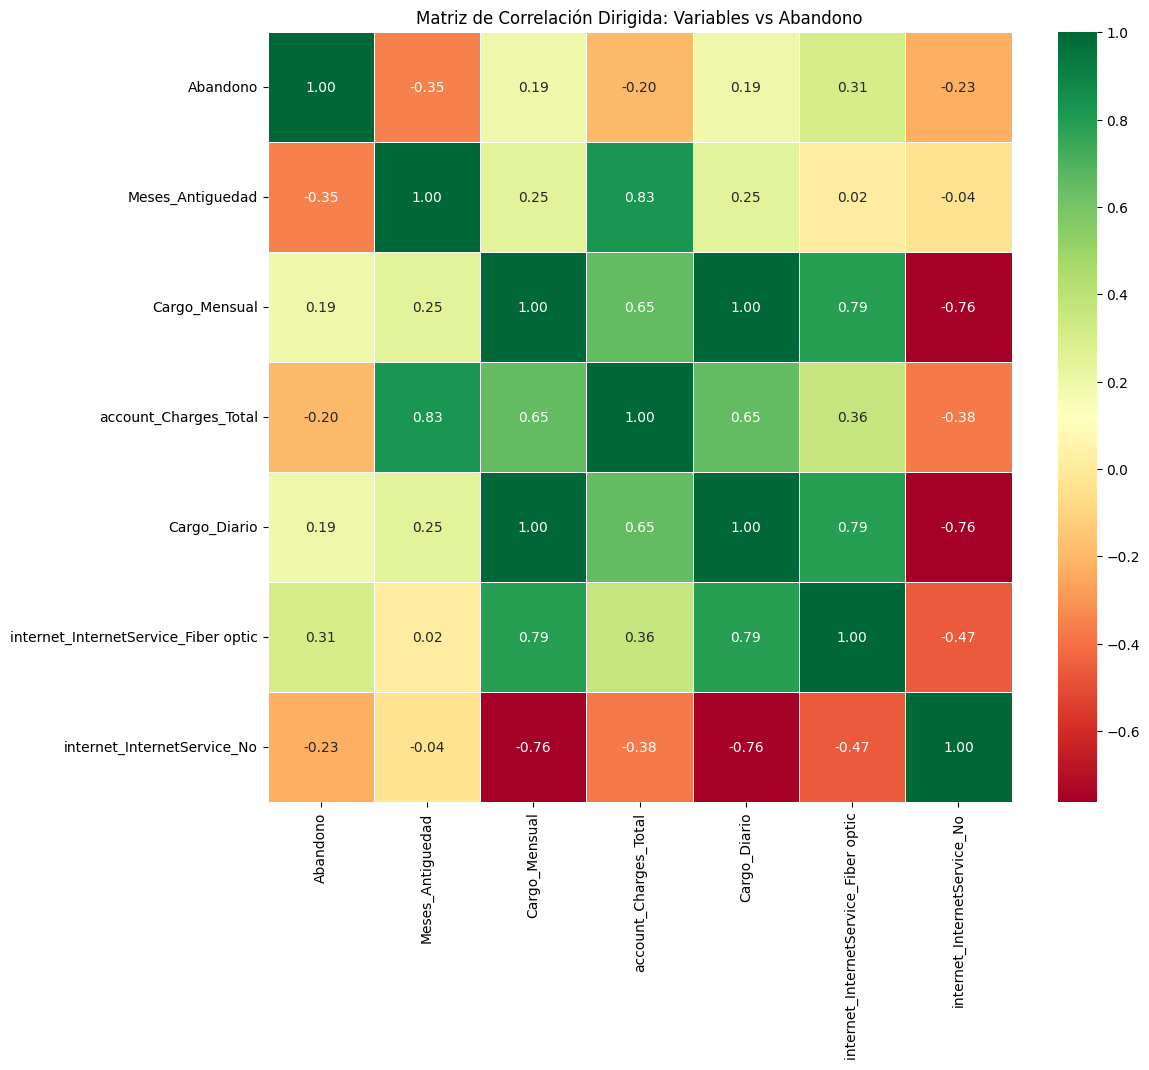

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_clave = ['Abandono', 'Meses_Antiguedad', 'Cargo_Mensual', 'Cargo_Diario', 'account_Charges_Total']
cols_interes = [col for col in df_encoded.columns if 'Contract' in col or 'Internet' in col or col in columnas_clave]

plt.figure(figsize=(12, 10))
matriz_corr = df_encoded[cols_interes].corr()

sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Dirigida: Variables vs Abandono')
plt.show()

2. Análisis Dirigido (Visualización de Patrones)

A. Tiempo de Contrato (Meses de Antigüedad) × Cancelación

/tmp/ipykernel_415/4116033883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='Abandono', y='Meses_Antiguedad', palette='Set2')


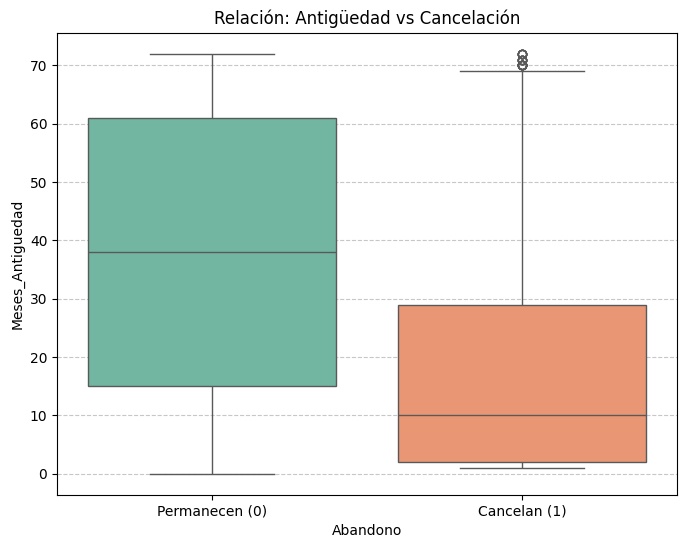

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_ml, x='Abandono', y='Meses_Antiguedad', palette='Set2')
plt.title('Relación: Antigüedad vs Cancelación')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

B. Gasto Total (account_Charges_Total) × Cancelación

/tmp/ipykernel_415/2089644760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x='Abandono', y='account_Charges_Total', palette='magma')


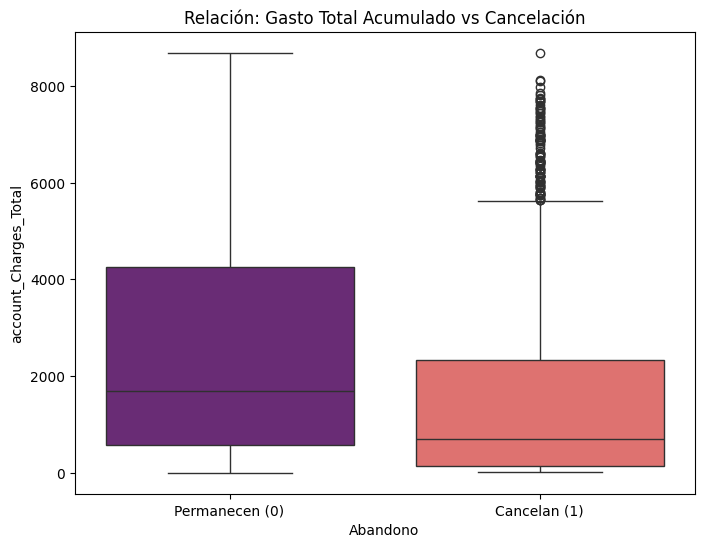

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_ml, x='Abandono', y='account_Charges_Total', palette='magma')
plt.title('Relación: Gasto Total Acumulado vs Cancelación')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.show()

# **Modelado Predictivo**

1. Separación y Preparación Final de Datos

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Separación de datos (80% entrenamiento, 20% prueba)
X = df_encoded.drop('Abandono', axis=1)
y = df_encoded['Abandono']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Normalización (Solo para modelos sensibles como Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos separados y escalados correctamente.")

Datos separados y escalados correctamente.


2. Creación y Entrenamiento de Modelos

Modelo A: Regresión Logística (Requiere Normalización)

Justificación: Este modelo utiliza una función sigmoide y optimización de coeficientes. Si no escalamos, una variable como "Cargos Totales" (miles) dominaría injustamente sobre "Adulto Mayor" (0 o 1), sesgando el resultado.

In [10]:
# Entrenamiento con datos escalados
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)
y_pred_log = modelo_log.predict(X_test_scaled)

Modelo B: Random Forest (No requiere Normalización)

Justificación: Al ser un conjunto de árboles de decisión que realizan particiones basadas en umbrales (ej. ¿es el cargo > 50?), la magnitud absoluta de los datos no afecta la lógica de la división.

In [11]:
# Entrenamiento con datos originales (sin escalar)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

3. Evaluación y Comparación de Métricas


--- Métricas: Regresión Logística ---
Exactitud: 0.7871
Precisión: 0.7176
Recall:    0.3262
F1-Score:  0.4485


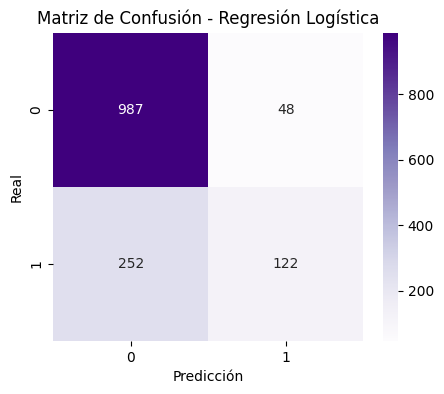


--- Métricas: Random Forest ---
Exactitud: 0.7935
Precisión: 0.6578
Recall:    0.4626
F1-Score:  0.5432


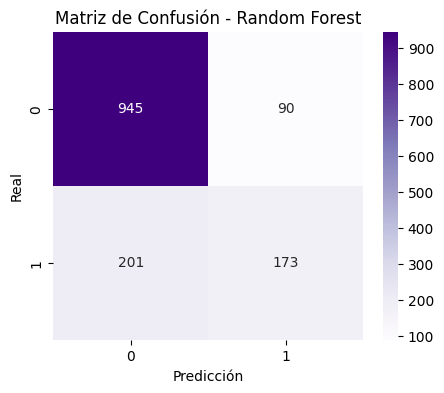

In [12]:
def mostrar_metricas(y_real, y_pred, nombre_modelo):
    print(f"\n--- Métricas: {nombre_modelo} ---")
    print(f"Exactitud: {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_real, y_pred):.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()

mostrar_metricas(y_test, y_pred_log, "Regresión Logística")
mostrar_metricas(y_test, y_pred_rf, "Random Forest")

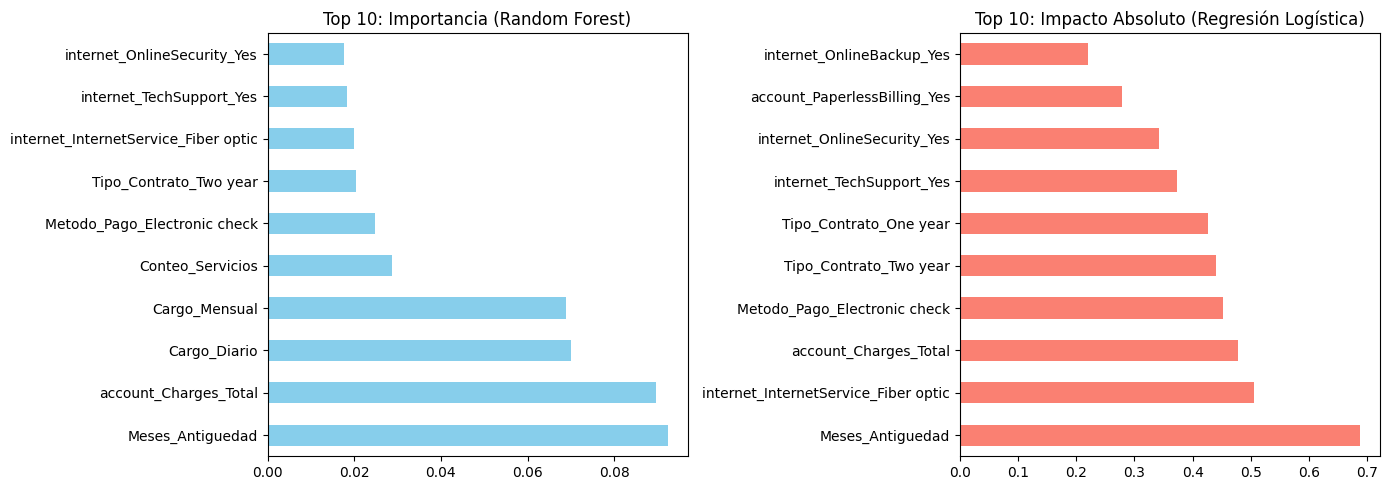

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Importancia en Random Forest ---
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns)
top_rf = importancias_rf.nlargest(10)

# --- 2. Coeficientes en Regresión Logística ---
importancias_log = pd.Series(modelo_log.coef_[0], index=X.columns)
top_log = importancias_log.abs().nlargest(10)

# Visualización
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
top_rf.plot(kind='barh', color='skyblue')
plt.title('Top 10: Importancia (Random Forest)')

plt.subplot(1, 2, 2)
top_log.plot(kind='barh', color='salmon')
plt.title('Top 10: Impacto Absoluto (Regresión Logística)')

plt.tight_layout()
plt.show()

Análisis de los Top Predictores
1. El Factor Tiempo es el Rey (Meses_Antiguedad):
En ambas gráficas, la antigüedad es la variable más importante por lejos. Esto confirma que los clientes más "nuevos" son los más propensos a irse. Si sobreviven los primeros meses, la probabilidad de fuga cae drásticamente.

2. La Sensibilidad al Precio (account_Charges_Total, Cargo_Diario, Cargo_Mensual):

El Random Forest le da muchísima importancia al gasto acumulado y al cargo diario.

La Regresión Logística confirma que el cargo total es un factor de impacto absoluto muy alto (casi 0.5).

Conclusión: El cliente de Telecom X es muy sensible al costo. Un aumento en la factura mensual dispara las alarmas de abandono.

3. El Riesgo de la Fibra Óptica (internet_InternetService_Fiber optic):
Es muy llamativo que la Fibra Óptica aparezca en el Top 3 de la Regresión Logística y en el Top 10 de Random Forest.

Insight: Los clientes con Fibra Óptica se están yendo más que los de DSL. ¿Es porque es más cara o porque el servicio técnico no está a la altura? Esto es un hallazgo crítico para la empresa.

4. Métodos de Pago y Contratos:

El Electronic check y los contratos a largo plazo (Two year, One year) aparecen con un peso importante. El cheque electrónico suele estar asociado a mayor morosidad o facilidad de cancelación manual, mientras que los contratos largos actúan como un ancla (impacto negativo en la fuga, es decir, retienen).

# **Conclusión Estratégica de Modelado Predictivo**

Tras analizar la importancia de las variables en los modelos de Random Forest y Regresión Logística, se concluye que la fidelización debe enfocarse en los clientes con baja Antigüedad y altos Cargos Mensuales.

Se ha identificado un patrón de riesgo específico en usuarios de Fibra Óptica y aquellos que utilizan Cheque Electrónico como método de pago.

Recomendaciones para Telecom X:

Campaña de Retención Temprana: Ofrecer bonificaciones de fidelidad a clientes entre el mes 1 y el mes 6.

Auditoría de Calidad en Fibra: Revisar la estabilidad del servicio de Fibra Óptica, ya que es un foco de deserción.

Migración de Pago: Incentivar el cambio de Cheque Electrónico a Débito Automático o Tarjeta de Crédito para reducir la fricción en la cobranza.